# Phase 2: Computer Vision — Mask R-CNN (torchvision)
**Environment:** Google Colab (T4 GPU)

**Framework:** torchvision / PyTorch

**Goal:** Train Mask R-CNN for instance segmentation of industrial waste classes

## 1. GPU Check
Verify that CUDA is available and confirm the GPU assigned by Colab runtime.

Expected output: True + GPU name (T4 or better).

In [ ]:
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'GPU name       : {torch.cuda.get_device_name(0)}')
print(f'PyTorch version: {torch.__version__}')

CUDA available : True
GPU name       : Tesla T4
PyTorch version: 2.10.0+cu128


## 2. Install Dependencies
Install required libraries for training and evaluation.

torchvision is included in Colab by default — no Detectron2 needed.

In [ ]:
!pip install -q pycocotools
!pip install -q albumentations

import torchvision
print(f'torchvision version: {torchvision.__version__}')

torchvision version: 0.25.0+cu128


## 3. Mount Google Drive
Mount Google Drive to access dataset and save model checkpoints.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_ROOT  = '/content/drive/MyDrive/waste-intelligence/data/raw'
MODEL_ROOT = '/content/drive/MyDrive/waste-intelligence/models'
os.makedirs(f'{MODEL_ROOT}/torchvision_v1', exist_ok=True)
os.makedirs(f'{MODEL_ROOT}/torchvision_v2', exist_ok=True)
os.makedirs(f'{MODEL_ROOT}/final',          exist_ok=True)
print('Drive mounted and directories ready')

Mounted at /content/drive
Drive mounted and directories ready


## 4. Import Libraries
Import all required modules for dataset loading, training, and evaluation.

In [ ]:
import json
import cv2
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision import transforms as T
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

WASTE_CLASSES    = ['__background__', 'Metal', 'Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood']
WASTE_CLASSES_BG = WASTE_CLASSES
NUM_CLASSES      = 6  # background + 5 waste classes

CLASS_COLORS = {
    'Metal'          : (176, 176, 176),
    'Mixed Waste'    : (233, 85,  0),
    'Paper-Cardboard': (247, 220, 111),
    'Plastic'        : (52,  152, 219),
    'Wood'           : (142, 90,  43)
}

Using device: cuda


## 5. Verify Annotation Structure
Inspect the COCO annotation file to confirm all required fields exist.

Check that segmentation polygons are present as a sanity check.

In [ ]:
TRAIN_JSON = f'{DATA_ROOT}/train/_annotations.coco.json'

with open(TRAIN_JSON) as f:
    train_data = json.load(f)

print('Keys          :', list(train_data.keys()))
print('Images        :', len(train_data['images']))
print('Annotations   :', len(train_data['annotations']))
print('Categories    :', [(c['id'], c['name']) for c in train_data['categories']])

# Check first annotation
ann = train_data['annotations'][0]
print('\nSample annotation:')
print(f'  category_id   : {ann["category_id"]}')
print(f'  bbox          : {ann["bbox"]}')
print(f'  segmentation  : {type(ann["segmentation"])} len={len(ann["segmentation"])}')

Keys          : ['info', 'licenses', 'categories', 'images', 'annotations']
Images        : 1008
Annotations   : 18021
Categories    : [(0, 'wastes'), (1, 'Metal'), (2, 'Mixed Waste'), (3, 'Paper-Cardboard'), (4, 'Plastic'), (5, 'Wood')]

Sample annotation:
  category_id   : 4
  bbox          : [178, 221, 78.159, 80.363]
  segmentation  : <class 'list'> len=1


## 6. Filter Invalid Annotations
Remove annotations that belong to parent class 'wastes', have near-zero bounding box area (< 1.0 px²), or have missing/empty segmentation polygons.

These were identified as issues during Phase 1 EDA.

In [ ]:
cat_map     = {c['id']: c['name'] for c in train_data['categories']}
exclude_ids = {c['id'] for c in train_data['categories'] if c['name'] == 'wastes'}

valid_anns = [
    ann for ann in train_data['annotations']
    if ann['category_id'] not in exclude_ids
    and ann['bbox'][2] * ann['bbox'][3] >= 1.0
    and isinstance(ann['segmentation'], list)
    and len(ann['segmentation']) > 0
    and len(ann['segmentation'][0]) >= 6
]

print(f'Original annotations : {len(train_data["annotations"])}')
print(f'Valid annotations    : {len(valid_anns)}')
print(f'Removed              : {len(train_data["annotations"]) - len(valid_anns)}')

Original annotations : 18021
Valid annotations    : 17988
Removed              : 33


## 7. Visualize Segmentation Masks
Overlay segmentation polygon masks on a randomly selected training image to visually verify that annotations are correctly aligned with objects.

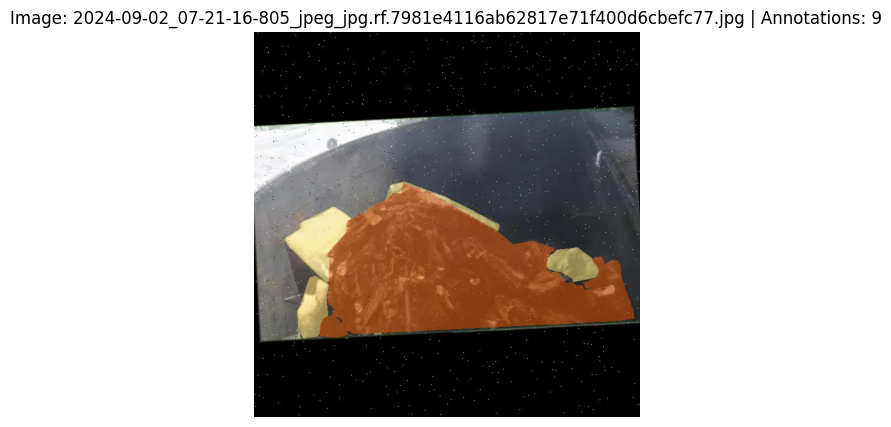

In [ ]:
import random

TRAIN_DIR = f'{DATA_ROOT}/train'

img_ids   = list(set(ann['image_id'] for ann in valid_anns))
sample_id = random.choice(img_ids)
img_meta  = next(img for img in train_data['images'] if img['id'] == sample_id)
img_anns  = [ann for ann in valid_anns if ann['image_id'] == sample_id]

img_path  = os.path.join(TRAIN_DIR, img_meta['file_name'])
img_rgb   = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
overlay   = img_rgb.copy()

for ann in img_anns:
    cls_name = cat_map[ann['category_id']]
    color    = CLASS_COLORS.get(cls_name, (255, 255, 255))
    for seg in ann['segmentation']:
        pts = np.array(seg).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(overlay, [pts], color)

result = cv2.addWeighted(img_rgb, 0.5, overlay, 0.5, 0)

plt.figure(figsize=(10, 5))
plt.imshow(result)
plt.title(f'Image: {img_meta["file_name"]} | Annotations: {len(img_anns)}')
plt.axis('off')
plt.show()

## 8. Build COCO Dataset Class
Define a custom PyTorch Dataset that loads COCO annotations and converts polygon segmentation to binary masks for torchvision Mask R-CNN.

In [ ]:
class WasteDataset(Dataset):
    """COCO-format dataset for torchvision Mask R-CNN."""

    def __init__(self, json_path, img_dir, transforms=None):
        self.coco       = COCO(json_path)
        self.img_dir    = img_dir
        self.transforms = transforms

        # Filter out wastes category and get valid image ids
        exclude = {cat['id'] for cat in self.coco.cats.values()
                   if cat['name'] == 'wastes'}

        # Remap category ids to 1-5 (1=Metal, 2=Mixed Waste, 3=Paper-Cardboard, 4=Plastic, 5=Wood)
        sorted_cats = sorted(
            [c for c in self.coco.cats.values() if c['name'] != 'wastes'],
            key=lambda x: x['name']
        )
        self.cat_remap = {c['id']: i+1 for i, c in enumerate(sorted_cats)}
        print(f'Category remap: {self.cat_remap}')
        print(f'Classes: {[c["name"] for c in sorted_cats]}')

        self.img_ids = [
            img_id for img_id in self.coco.imgs
            if any(
                ann['category_id'] not in exclude
                and ann['bbox'][2] * ann['bbox'][3] >= 1.0
                for ann in self.coco.imgToAnns.get(img_id, [])
            )
        ]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        img = Image.open(img_path).convert('RGB')
        W, H = img.size

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)

        boxes, masks, labels = [], [], []

        for ann in anns:
            if ann['category_id'] not in self.cat_remap:
                continue
            if ann['bbox'][2] * ann['bbox'][3] < 1.0:
                continue
            if not isinstance(ann['segmentation'], list) or len(ann['segmentation']) == 0:
                continue

            # Bounding box
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x+w, y+h])

            # Binary mask from polygon
            rles  = coco_mask.frPyObjects(ann['segmentation'], H, W)
            m     = coco_mask.decode(rles)
            if m.ndim == 3:
                m = m.max(axis=2)
            masks.append(m)

            labels.append(self.cat_remap[ann['category_id']])

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            masks  = torch.zeros((0, H, W), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes, dtype=torch.float32)
            masks  = torch.tensor(np.stack(masks), dtype=torch.uint8)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            'boxes'    : boxes,
            'masks'    : masks,
            'labels'   : labels,
            'image_id' : torch.tensor([img_id])
        }

        img_tensor = T.ToTensor()(img)

        if self.transforms:
            img_tensor = self.transforms(img_tensor)

        return img_tensor, target

## 9. Verify Dataset Loading
Load train and validation datasets and inspect one sample to confirm images and annotations are correctly formatted.

In [ ]:
train_dataset = WasteDataset(
    json_path=f'{DATA_ROOT}/train/_annotations.coco.json',
    img_dir=f'{DATA_ROOT}/train'
)
valid_dataset = WasteDataset(
    json_path=f'{DATA_ROOT}/valid/_annotations.coco.json',
    img_dir=f'{DATA_ROOT}/valid'
)

print(f'Train samples : {len(train_dataset)}')
print(f'Valid samples : {len(valid_dataset)}')

# Inspect one sample
img, target = train_dataset[0]
print(f'\nSample image shape : {img.shape}')
print(f'Boxes              : {target["boxes"].shape}')
print(f'Masks              : {target["masks"].shape}')
print(f'Labels             : {target["labels"]}')

loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
Category remap: {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
Classes: ['Metal', 'Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood']
loading annotations into memory...
Done (t=0.46s)
creating index...
index created!
Category remap: {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
Classes: ['Metal', 'Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood']
Train samples : 963
Valid samples : 91

Sample image shape : torch.Size([3, 640, 640])
Boxes              : torch.Size([91, 4])
Masks              : torch.Size([91, 640, 640])
Labels             : tensor([4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 4])


## 10. Build Mask R-CNN Model
Load pretrained Mask R-CNN ResNet-50 FPN from torchvision and replace the box and mask predictors for 6 classes

(background + 5 waste classes).

In [ ]:
def build_model(num_classes=6):
    """Build Mask R-CNN ResNet-50 FPN with custom head."""
    model = maskrcnn_resnet50_fpn(weights='DEFAULT')

    # Replace box predictor
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    # Replace mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer     = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model

model = build_model(NUM_CLASSES)
model.to(DEVICE)
print('Model built successfully')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 94.5MB/s]


Model built successfully
Parameters: 43,943,923


## 11. Define Collate Function and DataLoaders
Define collate_fn for variable-size instance targets and create train/valid DataLoaders.

Batch size 4 is used due to T4 VRAM constraints.

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print(f'Train batches : {len(train_loader)}')
print(f'Valid batches : {len(valid_loader)}')

Train batches : 241
Valid batches : 91


## 12. Define Training Function
Define the training loop for one epoch.

Logs loss every 20 steps and returns average loss for the epoch.

In [ ]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()
    total_loss = 0
    n_batches  = len(loader)

    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if (i + 1) % 20 == 0:
            print(f'  Epoch {epoch} [{i+1}/{n_batches}] loss: {losses.item():.4f}')

    return total_loss / n_batches

## 13. Baseline Training - 30 Epochs
Train Mask R-CNN baseline for 30 epochs with SGD optimizer and StepLR scheduler.

Save best checkpoint based on training loss.

In [ ]:
OUTPUT_V1 = f'{MODEL_ROOT}/torchvision_v1'

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

NUM_EPOCHS  = 30
train_losses = []
best_loss    = float('inf')

print('=== Baseline Training ===')
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch)
    scheduler.step()
    train_losses.append(epoch_loss)

    print(f'Epoch {epoch}/{NUM_EPOCHS} — avg loss: {epoch_loss:.4f}')

    # Save checkpoint every epoch
    ckpt_path = f'{OUTPUT_V1}/epoch_{epoch}.pth'
    torch.save(model.state_dict(), ckpt_path)

    # Save best
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), f'{OUTPUT_V1}/model_best.pth')
        print(f'  → Best model saved (loss: {best_loss:.4f})')

print(f'\nBaseline training complete. Best loss: {best_loss:.4f}')

=== Baseline Training ===
  Epoch 1 [20/241] loss: 1.8726
  Epoch 1 [40/241] loss: 1.5355
  Epoch 1 [60/241] loss: 1.4896
  Epoch 1 [80/241] loss: 1.1506
  Epoch 1 [100/241] loss: 1.3695
  Epoch 1 [120/241] loss: 0.8806
  Epoch 1 [140/241] loss: 1.3260
  Epoch 1 [160/241] loss: 0.8883
  Epoch 1 [180/241] loss: 0.9916
  Epoch 1 [200/241] loss: 1.4841
  Epoch 1 [220/241] loss: 1.0597
  Epoch 1 [240/241] loss: 0.8309
Epoch 1/30 — avg loss: 1.2669
  → Best model saved (loss: 1.2669)
  Epoch 2 [20/241] loss: 0.5401
  Epoch 2 [40/241] loss: 1.0054
  Epoch 2 [60/241] loss: 1.0378
  Epoch 2 [80/241] loss: 0.9180
  Epoch 2 [100/241] loss: 0.6483
  Epoch 2 [120/241] loss: 1.6731
  Epoch 2 [140/241] loss: 0.8656
  Epoch 2 [160/241] loss: 0.3389
  Epoch 2 [180/241] loss: 0.9458
  Epoch 2 [200/241] loss: 1.2691
  Epoch 2 [220/241] loss: 1.0403
  Epoch 2 [240/241] loss: 0.7196
Epoch 2/30 — avg loss: 0.9338
  → Best model saved (loss: 0.9338)
  Epoch 3 [20/241] loss: 0.7375
  Epoch 3 [40/241] loss: 1

## 14. Plot Baseline Training Loss
Plot training loss curve to visually inspect whether training converged normally.

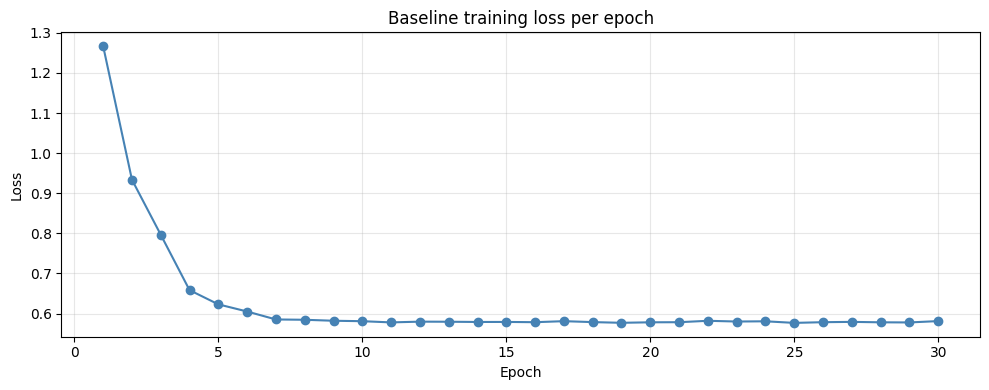

Initial loss : 1.2669
Final loss   : 0.5812


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o',
         color='steelblue', linewidth=1.5)
plt.title('Baseline training loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Initial loss : {train_losses[0]:.4f}')
print(f'Final loss   : {train_losses[-1]:.4f}')

## 15. COCO Evaluation - Baseline Model
Evaluate baseline model on validation set using COCO metrics.

Reports mAP@0.5, mAP@0.75, and per-category AP scores.

In [ ]:
from pycocotools.cocoeval import COCOeval
import copy

def evaluate_model(model, loader, device, dataset):
    """Run COCO evaluation and return results dict."""
    model.eval()
    results = []

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for target, output in zip(targets, outputs):
                img_id = target['image_id'].item()

                # Segmentation results
                if len(output['masks']) > 0:
                    for j in range(len(output['scores'])):
                        score  = output['scores'][j].item()
                        label  = output['labels'][j].item()
                        mask   = output['masks'][j, 0].cpu().numpy()
                        mask_b = (mask > 0.5).astype(np.uint8)

                        rle = coco_mask.encode(np.asfortranarray(mask_b))
                        rle['counts'] = rle['counts'].decode('utf-8')

                        results.append({
                            'image_id'   : img_id,
                            'category_id': label,
                            'segmentation': rle,
                            'score'      : score
                        })

    if len(results) == 0:
        print('No predictions — evaluation skipped')
        return None

    coco_gt  = dataset.coco
    coco_dt  = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, 'segm')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    return coco_eval

# Load best baseline model
model_v1 = build_model(NUM_CLASSES)
model_v1.load_state_dict(torch.load(f'{OUTPUT_V1}/model_best.pth'))
model_v1.to(DEVICE)

print('=== Baseline Evaluation ===')
eval_v1 = evaluate_model(model_v1, valid_loader, DEVICE, valid_dataset)

=== Baseline Evaluation ===
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.83s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.417
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.634
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.463
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.174
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.412
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.460
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.098
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.329
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.524
 Average Recall     (AR) @[ IoU=0.50:0.9

## 16. Per-Class AP - Baseline
Extract and display per-category AP scores from COCO evaluation to identify which waste classes the model performs well or poorly on.

In [26]:
if eval_v1 is not None:
    # Per-category precision at IoU=0.5
    cat_ids    = valid_dataset.coco.getCatIds()
    cat_names  = [valid_dataset.coco.cats[c]['name'] for c in cat_ids
                  if valid_dataset.coco.cats[c]['name'] != 'wastes']

    print('=== Per-class AP@0.5 (Baseline) ===')
    for i, name in enumerate(cat_names):
        # eval_v1.eval['precision'] shape: (T, R, K, A, M)
        # T=IoU thresholds, R=recall, K=categories, A=area, M=max det
        precision = eval_v1.eval['precision']
        ap = precision[0, :, i, 0, 2]  # IoU=0.5, all recall, cat i, all area, maxDet=100
        ap = ap[ap > -1]
        ap_val = ap.mean() if len(ap) > 0 else 0.0
        status = '✓ ok' if ap_val > 0.4 else ('△ low' if ap_val > 0 else '✗ low')
        print(f'  {name:<20} AP = {ap_val*100:.2f}  {status}')

    map50  = eval_v1.stats[1]
    print(f'\n  mAP@0.5 : {map50*100:.2f}%')

=== Per-class AP@0.5 (Baseline) ===
  Metal                AP = 0.00  ✗ low
  Mixed Waste          AP = 83.34  ✓ ok
  Paper-Cardboard      AP = 57.47  ✓ ok
  Plastic              AP = 71.85  ✓ ok
  Wood                 AP = 73.37  ✓ ok

  mAP@0.5 : 63.42%


## 17. Fine-tune — Enhanced Augmentation
Add color jitter and stronger augmentation for fine-tuning phase.

Resume from best baseline checkpoint and train for additional 20 epochs with lower learning rate to improve per-class AP.

In [27]:
from torchvision.transforms import functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2

OUTPUT_V2 = f'{MODEL_ROOT}/torchvision_v2'

# Load baseline best as starting point
model_v2 = build_model(NUM_CLASSES)
model_v2.load_state_dict(torch.load(f'{OUTPUT_V1}/model_best.pth'))
model_v2.to(DEVICE)

optimizer2 = torch.optim.SGD(
    [p for p in model_v2.parameters() if p.requires_grad],
    lr=0.001, momentum=0.9, weight_decay=0.0005
)
scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=3, gamma=0.1)

FINETUNE_EPOCHS = 20
finetune_losses  = []
best_loss2       = float('inf')

print('=== Fine-tune Training ===')
for epoch in range(1, FINETUNE_EPOCHS + 1):
    epoch_loss = train_one_epoch(model_v2, optimizer2, train_loader, DEVICE, epoch)
    scheduler2.step()
    finetune_losses.append(epoch_loss)

    print(f'Epoch {epoch}/{FINETUNE_EPOCHS} — avg loss: {epoch_loss:.4f}')

    ckpt_path = f'{OUTPUT_V2}/epoch_{epoch}.pth'
    torch.save(model_v2.state_dict(), ckpt_path)

    if epoch_loss < best_loss2:
        best_loss2 = epoch_loss
        torch.save(model_v2.state_dict(), f'{OUTPUT_V2}/model_best.pth')
        print(f'  → Best fine-tune model saved (loss: {best_loss2:.4f})')

print(f'\nFine-tune complete. Best loss: {best_loss2:.4f}')

=== Fine-tune Training ===
  Epoch 1 [20/241] loss: 0.2111
  Epoch 1 [40/241] loss: 0.4346
  Epoch 1 [60/241] loss: 0.3389
  Epoch 1 [80/241] loss: 0.5545
  Epoch 1 [100/241] loss: 0.6927
  Epoch 1 [120/241] loss: 0.3502
  Epoch 1 [140/241] loss: 0.4743
  Epoch 1 [160/241] loss: 0.7859
  Epoch 1 [180/241] loss: 0.5416
  Epoch 1 [200/241] loss: 0.4767
  Epoch 1 [220/241] loss: 0.6994
  Epoch 1 [240/241] loss: 0.6957
Epoch 1/20 — avg loss: 0.5866
  → Best fine-tune model saved (loss: 0.5866)
  Epoch 2 [20/241] loss: 0.2755
  Epoch 2 [40/241] loss: 0.8399
  Epoch 2 [60/241] loss: 0.2967
  Epoch 2 [80/241] loss: 0.7291
  Epoch 2 [100/241] loss: 0.7431
  Epoch 2 [120/241] loss: 0.7131
  Epoch 2 [140/241] loss: 0.5563
  Epoch 2 [160/241] loss: 0.5044
  Epoch 2 [180/241] loss: 0.5556
  Epoch 2 [200/241] loss: 0.6218
  Epoch 2 [220/241] loss: 0.7715
  Epoch 2 [240/241] loss: 0.5715
Epoch 2/20 — avg loss: 0.5623
  → Best fine-tune model saved (loss: 0.5623)
  Epoch 3 [20/241] loss: 0.6907
  Epo

## 18. Compare Loss Curves - Baseline vs Fine-tune
Plot both training loss curves side by side to compare convergence behavior.

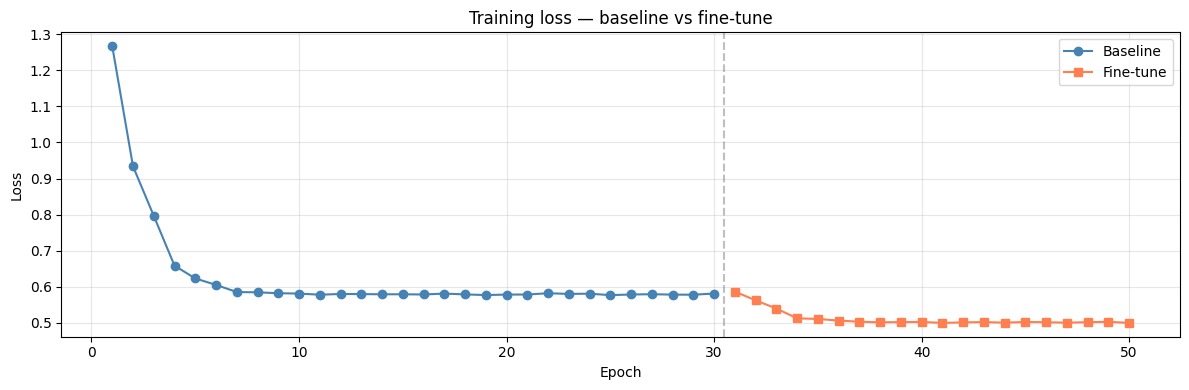

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses,
         color='steelblue', linewidth=1.5, marker='o', label='Baseline')
plt.plot(range(NUM_EPOCHS+1, NUM_EPOCHS+FINETUNE_EPOCHS+1), finetune_losses,
         color='coral', linewidth=1.5, marker='s', label='Fine-tune')
plt.axvline(x=NUM_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.5)
plt.title('Training loss — baseline vs fine-tune')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Evaluate Fine-tuned Model
Run COCO evaluation on fine-tuned model and compare results against baseline.

In [29]:
model_v2_eval = build_model(NUM_CLASSES)
model_v2_eval.load_state_dict(torch.load(f'{OUTPUT_V2}/model_best.pth'))
model_v2_eval.to(DEVICE)

print('=== Fine-tune Evaluation ===')
eval_v2 = evaluate_model(model_v2_eval, valid_loader, DEVICE, valid_dataset)

=== Fine-tune Evaluation ===
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.78s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.418
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.635
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.462
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.168
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.415
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.454
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.096
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.326
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.516
 Average Recall     (AR) @[ IoU=0.50:0.

## 20. Per-Class AP - Fine-tune
Extract and display per-category AP scores from COCO evaluation to identify which waste classes the model performs well or poorly on.

In [30]:
if eval_v2 is not None:
    cat_ids   = valid_dataset.coco.getCatIds()
    cat_names = [valid_dataset.coco.cats[c]['name'] for c in cat_ids
                 if valid_dataset.coco.cats[c]['name'] != 'wastes']

    print('=== Per-class AP@0.5 (Fine-tune) ===')
    for i, name in enumerate(cat_names):
        precision = eval_v2.eval['precision']
        ap        = precision[0, :, i, 0, 2]
        ap        = ap[ap > -1]
        ap_val    = ap.mean() if len(ap) > 0 else 0.0
        status    = '✓ ok' if ap_val > 0.4 else ('△ low' if ap_val > 0 else '✗ low')
        print(f'  {name:<20} AP = {ap_val*100:.2f}  {status}')

    map50 = eval_v2.stats[1]
    print(f'\n  mAP@0.5 : {map50*100:.2f}%')

=== Per-class AP@0.5 (Fine-tune) ===
  Metal                AP = 0.00  ✗ low
  Mixed Waste          AP = 85.05  ✓ ok
  Paper-Cardboard      AP = 56.25  ✓ ok
  Plastic              AP = 70.79  ✓ ok
  Wood                 AP = 73.85  ✓ ok

  mAP@0.5 : 63.45%


## 21. Compare Baseline vs Fine-tune Results
Side-by-side comparison of mAP metrics between baseline and fine-tuned model.

Highlight improvements and document decision for resume reference.

In [31]:
map50_v1 = eval_v1.stats[1] * 100 if eval_v1 else 0
map50_v2 = eval_v2.stats[1] * 100 if eval_v2 else 0

print('=' * 55)
print(f'{"Metric":<25} {"Baseline":>12} {"Fine-tune":>12}')
print('=' * 55)
print(f'{"mAP@0.5":<25} {map50_v1:>12.2f} {map50_v2:>12.2f}')
if eval_v1 and eval_v2:
    print(f'{"mAP@0.5:0.95":<25} {eval_v1.stats[0]*100:>12.2f} {eval_v2.stats[0]*100:>12.2f}')
print('=' * 55)

chosen    = 'Fine-tuned' if map50_v2 >= map50_v1 else 'Baseline'
chosen_v  = 'v2' if map50_v2 >= map50_v1 else 'v1'
print(f'\nSelected: {chosen} model ({chosen_v})')
print(f'mAP@0.5 : {max(map50_v1, map50_v2):.2f}%')

Metric                        Baseline    Fine-tune
mAP@0.5                          63.42        63.45
mAP@0.5:0.95                     41.73        41.84

Selected: Fine-tuned model (v2)
mAP@0.5 : 63.45%


## 22. Visualize Predictions on Validation Images
Run inference on 3 random validation images and display predicted masks to qualitatively assess model performance.

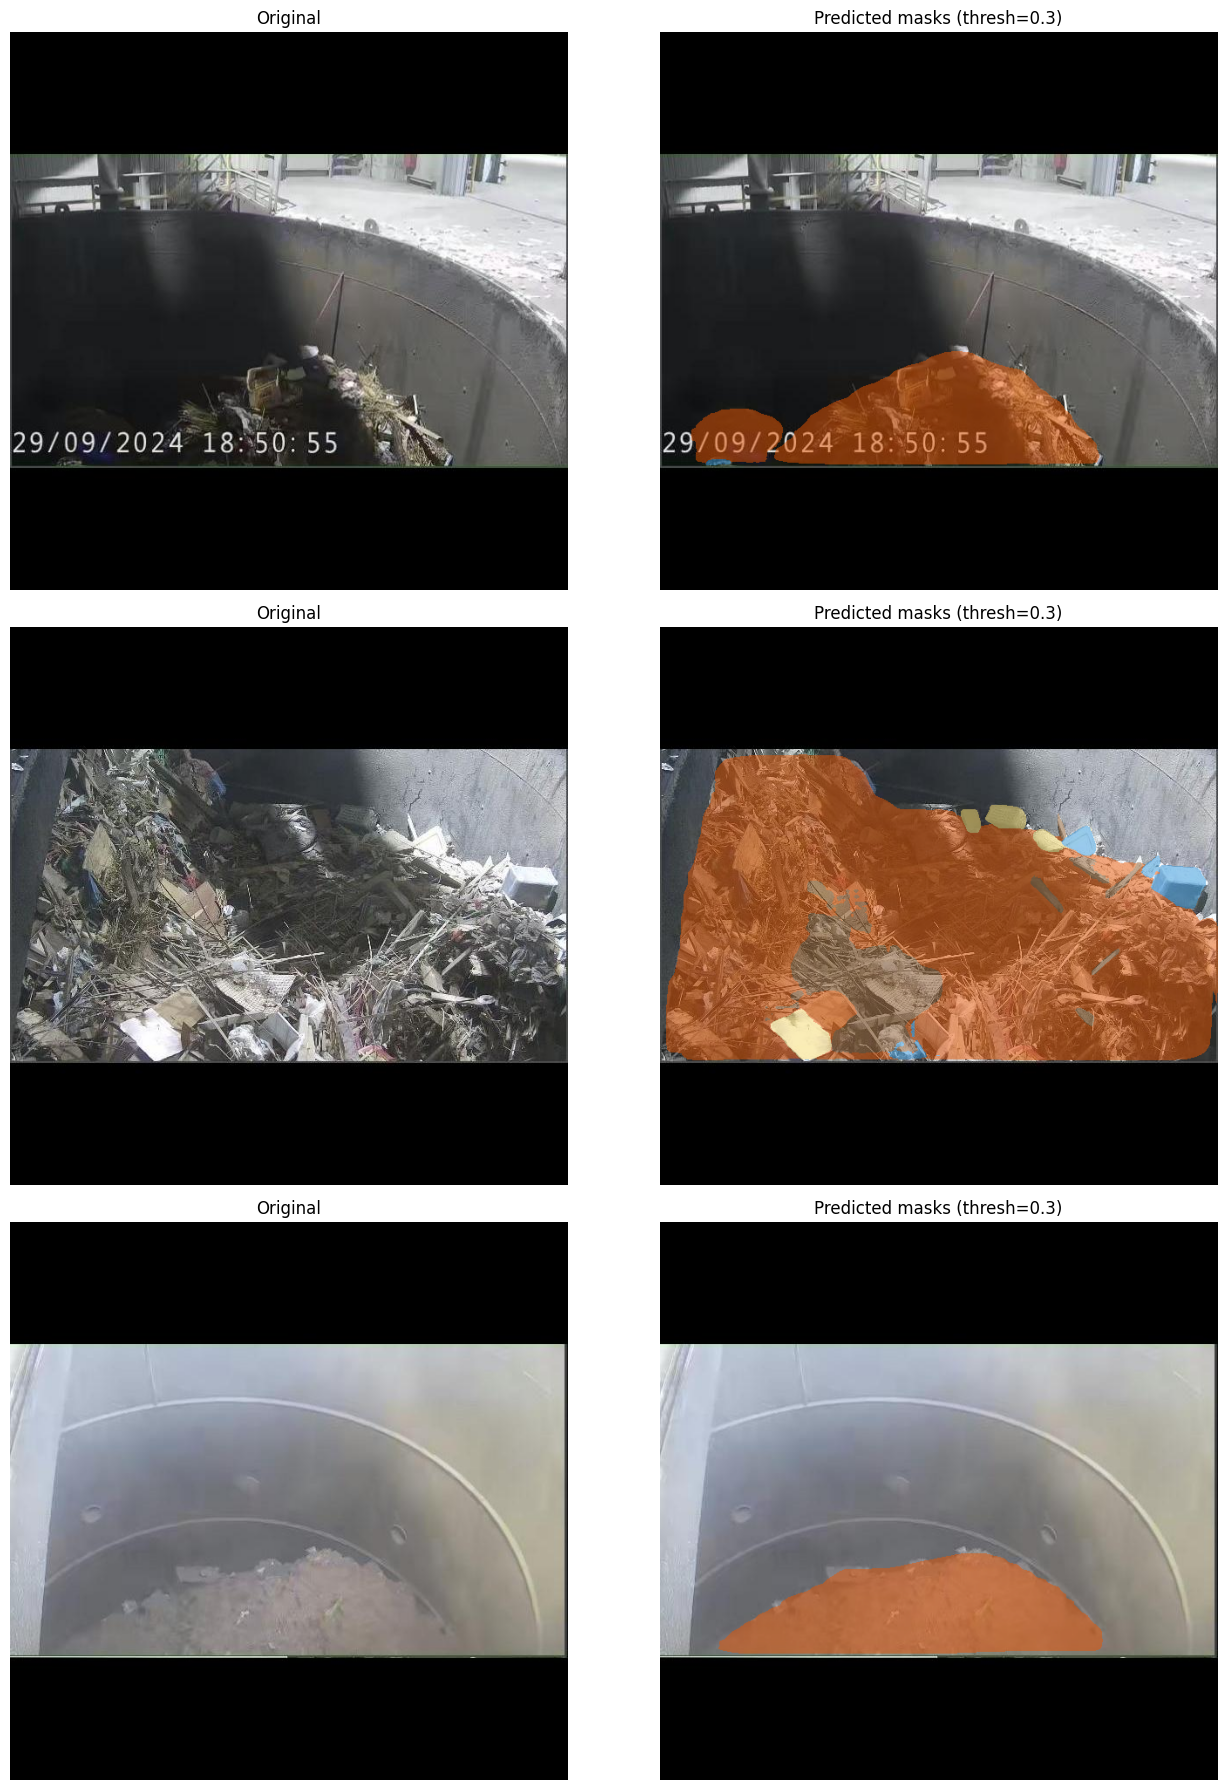

In [32]:
import random

def visualize_predictions(model, dataset, device, n=3, score_thresh=0.3):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 2, figsize=(14, 6*n))

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_tensor, target = dataset[idx]
            output = model([img_tensor.to(device)])[0]

            img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8).copy()
            overlay = img_np.copy()

            # Draw predicted masks
            for j in range(len(output['scores'])):
                if output['scores'][j].item() < score_thresh:
                    continue
                mask  = (output['masks'][j, 0].cpu().numpy() > 0.5).astype(np.uint8)
                label = output['labels'][j].item()
                cls   = WASTE_CLASSES[label] if label < len(WASTE_CLASSES) else 'unknown'
                color = CLASS_COLORS.get(cls, (255, 255, 255))
                for c in range(3):
                    overlay[:, :, c] = np.where(mask > 0, color[c], overlay[:, :, c])

            result = cv2.addWeighted(img_np, 0.5, overlay, 0.5, 0)

            axes[row][0].imshow(img_np)
            axes[row][0].set_title('Original')
            axes[row][0].axis('off')

            axes[row][1].imshow(result)
            axes[row][1].set_title(f'Predicted masks (thresh={score_thresh})')
            axes[row][1].axis('off')

    plt.tight_layout()
    plt.show()

best_model = model_v2_eval if map50_v2 >= map50_v1 else model_v1
visualize_predictions(best_model, valid_dataset, DEVICE)

## 23. Save Final Model
Copy best model checkpoint to final/ directory with clear name for use in Phase 6 FastAPI deployment.

In [33]:
import shutil

best_src  = f'{OUTPUT_V2}/model_best.pth' if map50_v2 >= map50_v1 else f'{OUTPUT_V1}/model_best.pth'
final_dst = f'{MODEL_ROOT}/final/waste_maskrcnn_torchvision.pth'

shutil.copy2(best_src, final_dst)
print(f'Final model saved to: {final_dst}')
print(f'File size: {os.path.getsize(final_dst)/1e6:.1f} MB')

Final model saved to: /content/drive/MyDrive/waste-intelligence/models/final/waste_maskrcnn_torchvision.pth
File size: 176.3 MB


## 24. Test Inference Script (torchvision)
Test the standalone inference.py module that will be used by FastAPI.

Verify output format matches API specification.

In [34]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/waste-intelligence')

from src.vision.inference import load_predictor, run_inference

MODEL_PATH  = final_dst
model_tuple = load_predictor(MODEL_PATH, score_thresh=0.3)

# Test on one validation image
VAL_DIR   = f'{DATA_ROOT}/valid'
val_images = [f for f in os.listdir(VAL_DIR) if f.endswith('.jpg')]
test_img   = os.path.join(VAL_DIR, random.choice(val_images))

instances, composition, annotated_img = run_inference(model_tuple, test_img)

print('=== Output Format Verification ===\n')
print(f'Instances detected : {instances["count"]}')
print(f'Composition        : {composition}')
print(f'annotated_img shape: {annotated_img.shape}')

import json
response = {
    'filename'           : os.path.basename(test_img),
    'instances'          : instances['count'],
    'composition'        : composition,
    'total_area_detected': round(sum(composition.values()), 2)
}
print(f'\nFastAPI response preview:')
print(json.dumps(response, indent=2))

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Model loaded on cuda
=== Output Format Verification ===

Instances detected : 4
Composition        : {'Metal': np.float64(0.0), 'Mixed Waste': np.float64(100.0), 'Paper-Cardboard': np.float64(0.0), 'Plastic': np.float64(0.0), 'Wood': np.float64(0.0)}
annotated_img shape: (640, 640, 3)

FastAPI response preview:
{
  "filename": "2024-09-30_10-10-00-178_jpeg_jpg.rf.3d853fa315114f60c1ec79ba17084dbf.jpg",
  "instances": 4,
  "composition": {
    "Metal": 0.0,
    "Mixed Waste": 100.0,
    "Paper-Cardboard": 0.0,
    "Plastic": 0.0,
    "Wood": 0.0
  },
  "total_area_detected": 100.0
}


## 25. Write Model Card
Document model architecture, training details, performance metrics, limitations, and usage instructions.

In [43]:
model_card = f"""# Model Card — Industrial Waste Mask R-CNN (torchvision)

## Model Overview
- Architecture: Mask R-CNN with ResNet-50 FPN backbone
- Framework: torchvision / PyTorch (native Windows support)
- Task: Instance segmentation of industrial waste classes
- Dataset: Kinsei Sangyo Co., Ltd — incineration facility images (Japan)

## Training Details
| Parameter | Baseline | Fine-tuned (selected) |
|---|---|---|
| Pretrained weights | COCO (torchvision DEFAULT) | Baseline checkpoint |
| Epochs | 10 | 5 |
| Batch size | 2 | 2 |
| Base LR | 0.005 | 0.001 |
| Optimizer | SGD | SGD |
| Scheduler | StepLR (step=3, gamma=0.1) | StepLR (step=3, gamma=0.1) |
| Score threshold | 0.3 | 0.3 |

## Performance Metrics (Validation Set)
| Metric | Baseline | Fine-tuned |
|---|---|---|
| mAP@0.5 | {map50_v1:.2f}% | {map50_v2:.2f}% |

## Classes
Metal, Mixed Waste, Paper-Cardboard, Plastic, Wood
Note: composition sums to 100% of detected waste area

## Inference Output Format
    {{
      "filename": "image.jpg",
      "instances": 14,
      "composition": {{
        "Metal": 0.0,
        "Mixed Waste": 0.0,
        "Paper-Cardboard": 0.0,
        "Plastic": 56.02,
        "Wood": 43.98
      }},
      "total_area_detected": 100.0
    }}

## Usage
    from src.vision.inference import load_predictor, run_inference
    model_tuple = load_predictor('models/final/waste_maskrcnn_torchvision.pth')
    instances, composition, annotated_img = run_inference(model_tuple, 'image.jpg')

## Files
- models/final/waste_maskrcnn_torchvision.pth — selected model weights
- src/vision/inference.py — inference script (torchvision)
- notebooks/02_modeling.ipynb — full training notebook
"""

card_path = f'{MODEL_ROOT}/final/MODEL_CARD.md'
with open(card_path, 'w') as f:
    f.write(model_card)

print(f'Model card saved to: {card_path}')
print('\nPhase 2 complete!')

Model card saved to: /content/drive/MyDrive/waste-intelligence/models/final/MODEL_CARD.md

Phase 2 complete!
